In [116]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [117]:
df = df = pd.read_csv("vgsales.csv.zip")
df

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.00,0.00,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.00,0.00,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01


In [118]:
df.describe()
#it was best to see desc before filling as we can see year was has missing values because years != rank 
#NA-sales = On average, each game sold 0.264 million copies in North America.(think same as this for others)
#the data  is right skewed as you can see the mean was > than 50% (median)

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


In [119]:
df.isnull().sum()
#So describe() + isnull() helps us diagnose the dataset before we change anything.

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

In [120]:
df.duplicated().sum()

np.int64(0)

In [121]:
df.columns

Index(['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales'],
      dtype='str')

In [122]:
df.nunique()
#rank has unique vales (eligibe for index(primary key)
#analyse there how many unique values available in each attribute 

Rank            16598
Name            11493
Platform           31
Year               39
Genre              12
Publisher         578
NA_Sales          409
EU_Sales          305
JP_Sales          244
Other_Sales       157
Global_Sales      623
dtype: int64

In [123]:
df['Year'].isnull().sum() #checking the missing values in year

np.int64(271)

In [124]:
#year cant be gussed as it will affect the accuracy of the data much and missing values covers 1.6% of the data so it was↓
#best idea to drop the missing years 


df=df.dropna(subset=['Year'])  #dropna → will drop na(NaN) values (see the whole syntax)
df['Year'].isnull().sum()

np.int64(0)

In [125]:
df.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16327.000000,16327.000000,16327.000000,16327.000000,16327.000000,16327.000000,16327.000000
mean,8292.868194,2006.406443,0.265415,0.147554,0.078661,0.048325,0.540232
std,4792.669778,5.828981,0.821591,0.508766,0.311557,0.189885,1.565732
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4136.500000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8295.000000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12441.500000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.480000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


In [126]:
df['Publisher'].isnull().sum()

np.int64(36)

In [127]:
#removing the publisher might remove existence of some game completely and also remove some important values so  it was best to name unknown

df['Publisher']=df['Publisher'].fillna('unknown')  #fillna → to fill the na(NaN) with the given name  (see the whole syntax)
df['Publisher'].isnull().sum()

np.int64(0)

In [128]:
df.loc[df['Publisher']=='unknown']

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
1662,1664,Shrek / Shrek 2 2-in-1 Gameboy Advance Video,GBA,2007.0,Misc,unknown,0.87,0.32,0.00,0.02,1.21
2222,2224,Bentley's Hackpack,GBA,2005.0,Misc,unknown,0.67,0.25,0.00,0.02,0.93
3159,3161,Nicktoons Collection: Game Boy Advance Video V...,GBA,2004.0,Misc,unknown,0.46,0.17,0.00,0.01,0.64
3166,3168,SpongeBob SquarePants: Game Boy Advance Video ...,GBA,2004.0,Misc,unknown,0.46,0.17,0.00,0.01,0.64
3766,3768,SpongeBob SquarePants: Game Boy Advance Video ...,GBA,2004.0,Misc,unknown,0.38,0.14,0.00,0.01,0.53
4526,4528,The Fairly Odd Parents: Game Boy Advance Video...,GBA,2004.0,Misc,unknown,0.31,0.11,0.00,0.01,0.43
4635,4637,The Fairly Odd Parents: Game Boy Advance Video...,GBA,2004.0,Misc,unknown,0.30,0.11,0.00,0.01,0.42
5647,5649,Cartoon Network Collection: Game Boy Advance V...,GBA,2005.0,Misc,unknown,0.23,0.08,0.00,0.01,0.32
6437,6439,Sonic X: Game Boy Advance Video Volume 1,GBA,2004.0,Misc,unknown,0.19,0.07,0.00,0.00,0.27
6562,6564,Dora the Explorer: Game Boy Advance Video Volu...,GBA,2004.0,Misc,unknown,0.18,0.07,0.00,0.00,0.26


In [129]:
#dtype conversion for the year → the year was in float so changing to integer

df['Year']=df['Year'].astype(int)  #dtype conversion  syntax
df.info()

<class 'pandas.DataFrame'>
Index: 16327 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16327 non-null  int64  
 1   Name          16327 non-null  str    
 2   Platform      16327 non-null  str    
 3   Year          16327 non-null  int64  
 4   Genre         16327 non-null  str    
 5   Publisher     16327 non-null  str    
 6   NA_Sales      16327 non-null  float64
 7   EU_Sales      16327 non-null  float64
 8   JP_Sales      16327 non-null  float64
 9   Other_Sales   16327 non-null  float64
 10  Global_Sales  16327 non-null  float64
dtypes: float64(5), int64(2), str(4)
memory usage: 1.5 MB


In [130]:
df.columns

Index(['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales'],
      dtype='str')

In [131]:
df.loc[df['Global_Sales']==82.74]  #first run without loc the enter the max value to find the max(row)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74


In [132]:
#finding the highest sold game with a professional syntax

df.loc[df['Global_Sales']== df['Global_Sales'].max()]  

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74


In [133]:
#sorting top 10 most selling in descending values in global_sales to see the top selling games row

#this shows the 'Wii sports' games from year '2006' got the most sales 

#North America contributed the largest share of sales for this game. 

#'JP'  shows the least sales of the most selling game shows the game was not popular compared to other region

#Many of the top-selling games appear to be published by Nintendo.

#Many of the top 10 best-selling games are published by Nintendo

#As we can see the huge differnence btween the top 2 most selling game shows the data has a single huge outliers. makes the mean a little risky 
#to use


df.sort_values(by='Global_Sales',ascending=False).head(10)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
5,6,Tetris,GB,1989,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26
6,7,New Super Mario Bros.,DS,2006,Platform,Nintendo,11.38,9.23,6.50,2.90,30.01
7,8,Wii Play,Wii,2006,Misc,Nintendo,14.03,9.20,2.93,2.85,29.02
8,9,New Super Mario Bros. Wii,Wii,2009,Platform,Nintendo,14.59,7.06,4.70,2.26,28.62
9,10,Duck Hunt,NES,1984,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31


In [134]:
#syntax to group the total sales by platform and using sort_values sorted in descending order

df.groupby('Platform')['Global_Sales'].sum().sort_values(ascending=False)

#Even though Wii and NES appear in the top selling list, PS2 wins the higest market sales with its variety and Sum of games with a 
#whopping 1233.46 sales where wii went to 4th place infact of being dominant in top sales 

#PS2 likely had a very large game library and strong overall game sales.

#Wii seems to be having few top games along with some good games but it might also be Wii realsed less games 

#Therefore, this shows PS2 ans X360 holds most of the customers and top sales

#PS2 and X360 has a huge difference in sales 

#after PS2 all the other platform has very competitive markets with very less differnce in sales 



#Observation:
#PS2 has the highest total sales.

#Possible explanation:
#PS2 likely had a large number of successful game releases. → professional way of doing

#Next analysis:
#Check number of games released per platform.


Platform
PS2     1233.46
X360     969.61
PS3      949.35
Wii      909.81
DS       818.96
PS       727.39
GBA      313.56
PSP      291.71
PS4      278.10
PC       255.05
GB       254.42
XB       252.09
NES      251.07
3DS      246.28
N64      218.21
SNES     200.05
GC       197.14
XOne     141.06
2600      86.57
WiiU      81.86
PSV       61.63
SAT       33.59
GEN       28.36
DC        15.97
SCD        1.87
NG         1.44
WS         1.42
TG16       0.16
3DO        0.10
GG         0.04
PCFX       0.03
Name: Global_Sales, dtype: float64

In [135]:
df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)

#Observation:
#Action Genre games has a huge sales in the makket(1722.88)
#and there is a big differnce between action and remaining

#Possible explanation:
#action might have a wide range of games compared to other Genre
#people might like more Action types of games 

#Observation:
#top 2 has a huge variance and from 8 the sales has been declied so much, shows the data has a huge variannce in every aspect

#Possible explanation:
#People tends to play more of fewer genre and remanning feels letf out


Genre
Action          1722.88
Sports          1309.24
Shooter         1026.20
Role-Playing     923.84
Platform         829.15
Misc             797.62
Racing           726.77
Fighting         444.05
Simulation       390.16
Puzzle           242.22
Adventure        234.80
Strategy         173.43
Name: Global_Sales, dtype: float64

In [136]:
df.groupby('Publisher')['Global_Sales'].sum().sort_values(ascending=False).head(10)

#Observation:
#Nintendo is the leading publisher by total global sales, significantly outperforming other publishers.
#The sales distribution among publishers appears highly concentrated among a few dominant publishers, while most publishers contribute relatively small total sales.
#Nintendo  as we can see the outliner clearly in the top  10 itslf as top 1 was at 1784 and down within 10th position the sales declined to 253↓
#shows the data was few top selling and remaning was shawdowed by the game gaints like Nintendo, Electronic Arts   ect....


#Possible explanation:
# Top 4 might publish more games than others 
# One possible explanation is that established publishers may benefit from stronger brand recognition, which could contribute to higher overall sales.
# there are so many publishers so customers always bound to go top publishers 

Publisher
Nintendo                        1784.43
Electronic Arts                 1093.39
Activision                       721.41
Sony Computer Entertainment      607.28
Ubisoft                          473.54
Take-Two Interactive             399.30
THQ                              340.44
Konami Digital Entertainment     278.56
Sega                             270.70
Namco Bandai Games               253.65
Name: Global_Sales, dtype: float64

In [137]:
df.groupby('Publisher')['Name'].count().sort_values(ascending=False).head(10)


#Observation:
# A shock that Nintendo didnt appear in the stop shows Nintendo was very strong as it has more sales with fewer games comparitively
#This shows Nintendo seems to be having more promising game , thats why it generating more even with less games 
#electronics arts focus on qunatitive sales as they released more games in order to make a good  sale in market
#the variance was not too high except(Electronic Arts ) but this shows more choose qualitative and some choose quantitave 
#Nintendo shows the dominance in the market with strong sales with less games they soley focus on quality where Electronic Arts does the oppsite




#Possible explanation:
#Nintendo achieves high total sales despite releasing fewer games, suggesting their games may generate higher average sales per title.
#Electronic Arts might be being in the market for long time so they made more games
#Nintendo may develop the game in the most selling genre 
#Electronic Arts  may cover evry genre to catch every type of audience


#Next analysis:
#have to check Nintendo ferqunecy of releasing games using year to see they're making quality game (quality game takes time)
#have to check Electronic Arts ferqunecy of releasing games using year to see they're making more games in less time (quantity approach)

Publisher
Electronic Arts                 1339
Activision                       966
Namco Bandai Games               928
Ubisoft                          918
Konami Digital Entertainment     823
THQ                              712
Nintendo                         696
Sony Computer Entertainment      682
Sega                             632
Take-Two Interactive             412
Name: Name, dtype: int64

In [138]:
df.groupby('Publisher')['Global_Sales'].mean().sort_values(ascending=False).head(10)

#note:
#this was wrong EDA,this is called small sample problem↓
#where average might be misleading with uneven or noisier data as we can see palcom as realsed very few games so the avg went to top 


#solution:
#to avoid this make the sample even and less noisier 
#eg → make sample as atleast 50 games realeased to reduce the noise

Publisher
Palcom                                4.170000
Red Orb                               2.620000
Nintendo                              2.563836
Arena Entertainment                   2.360000
UEP Systems                           2.250000
RedOctane                             2.170000
Valve                                 1.740000
Hello Games                           1.600000
Sony Computer Entertainment Europe    1.592667
Westwood Studios                      1.550000
Name: Global_Sales, dtype: float64

In [139]:
df[df['Publisher'] == 'Palcom']['Name'].count()
#see palcom has released one game with 4.17 overall sales so the avg for this was 4.17 (very high compared to top selling publishers)

np.int64(1)

In [140]:
#making a new table to see the avg for the each game and the total sales 


pub_sum = df.groupby('Publisher')['Global_Sales'].sum() #variable for sum of sales by punlisher

pub_count = df.groupby('Publisher')['Name'].count()  #variable for count of games by each publisher

summary = pd.concat([pub_sum, pub_count], axis=1) #concating 2 variables in column stacked wise

summary.columns = ['Total_Sales', 'Game_Count'] #renaming the columns

summary['Avg_Sales'] = summary['Total_Sales'] / summary['Game_Count'] #creating a new column for avg for each game count

summary = summary.sort_values(by='Total_Sales', ascending=False).head(10) #sorting the values in descending order

summary


#Observation:
#Nintendo shows a significantly higher average sales per game compared to other publishers shows the dominance of the publisher in the field
#Other publishers show relatively similar average sales per game, indicating closer competition among them.
#and the tables shows some could have failed to be part in both qualitative and quantitavies like Namco Bandai Games ↓
#despite having a emerous amount of games and still managed very low average shows a seveier concerns on the publisher
#As we can Nintendo have very notable difference in top 10  shows the competition was high in top tier publishers 


#Possible explanation:
#Nintendo could have to best games selection among others also in quality of the games made them to outshadow other publishers
#the neck to neck competition among other top tier publisher can be seen clearly here  
#Some publishers, such as Namco Bandai Games, appear to rely on a high volume of game releases to achieve strong total sales. 
#Nintendo might be having the best games and build a trust for over the period while other shows significant improvement but yet need a lot ↓
#to catch up with the top 1 


#Next analysis:
#to see the  gap of each game release to check the publisher choose good quality or qunatity
#yearly improvement to check which publisher adopted the current gen gamning prefernece 
#check the recent sales and avg to forecaste the upcoming big publisher in the list 
#check the sales and variance of the Nintendo publisher wether they were consisten or sudden growth to forecast they're future state in top tier

#Analyze total global sales by year to identify industry trends.(next step)

,Total_Sales,Game_Count,Avg_Sales
Publisher,,,
Nintendo,1784.43,696,2.563836
Electronic Arts,1093.39,1339,0.816572
Activision,721.41,966,0.746801
Sony Computer Entertainment,607.28,682,0.890440
Ubisoft,473.54,918,0.515839
Take-Two Interactive,399.30,412,0.969175
THQ,340.44,712,0.478146
Konami Digital Entertainment,278.56,823,0.338469
Sega,270.70,632,0.428323


In [141]:
df[df['Publisher'] == 'Electronic Arts' ] ['Global_Sales'].mean()

np.float64(0.8165720687079911)

In [142]:
sale_trend = df.groupby('Year')['Global_Sales'].sum()
sale_trend

#Observation:
#Global video game sales show a steady growth trend until around 2010–2011, after which a noticeable decline begins
#Sales begin accelerating significantly after the mid-1990s, indicating industry expansion 
#Following the peak, sales decline sharply over the next few years, indicating a potential shift in the gaming market
#The peak period was at 2007 to 2010 with and avg of 600+ and 2008 holds the top sales with 678+


#Possible explanation:
#Sales were relatively low in the early 1980s, followed by gradual growth
#The gamimg prime time started after the time around 1995 with an significant spike in sale 
#Every trend has and decline stage and this data this might start around 2011(require strong analysis to prove)
#The decline after 2011 may be associated with the transition to digital distribution, mobile gaming, or changes in console cycles
#Some most popular games might relase on the time of 2007 to 2010 to make the sales trend sky rocketed 


#Next analysis:
#check the games relased by very year to find the more game relased year made good sale
#focus on the 2007 to 2010 with sales, game released with top publisher to see the reason behind the spike 
#Find the reason behind the sudden fall like less game released or game trend gone etc....

Year
1980     11.38
1981     35.77
1982     28.86
1983     16.79
1984     50.36
1985     53.94
1986     37.07
1987     21.74
1988     47.22
1989     73.45
1990     49.39
1991     32.23
1992     76.16
1993     45.98
1994     79.17
1995     88.11
1996    199.15
1997    200.98
1998    256.47
1999    251.27
2000    201.56
2001    331.47
2002    395.52
2003    357.85
2004    419.31
2005    459.94
2006    521.04
2007    611.13
2008    678.90
2009    667.30
2010    600.45
2011    515.99
2012    363.54
2013    368.11
2014    337.05
2015    264.44
2016     70.93
2017      0.05
2020      0.29
Name: Global_Sales, dtype: float64

In [143]:
g_per_yr = df.groupby('Year')['Name'].count()

g_per_yr


#Observation:
#This clear an hypothesis as the sales increase as the more games 
#When the game increase the sale icrease shows a correlation game and sales 


#Possible explanation:
#Game relase might decrease due to some factor like less sales etc.....


#Next analysis:
#concat game release per year and sale per year
#Correlation between sale and game 


Year
1980       9
1981      46
1982      36
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      41
1992      43
1993      60
1994     121
1995     219
1996     263
1997     289
1998     379
1999     338
2000     349
2001     482
2002     829
2003     775
2004     763
2005     941
2006    1008
2007    1202
2008    1428
2009    1431
2010    1259
2011    1139
2012     657
2013     546
2014     582
2015     614
2016     344
2017       3
2020       1
Name: Name, dtype: int64

<Axes: xlabel='Year'>

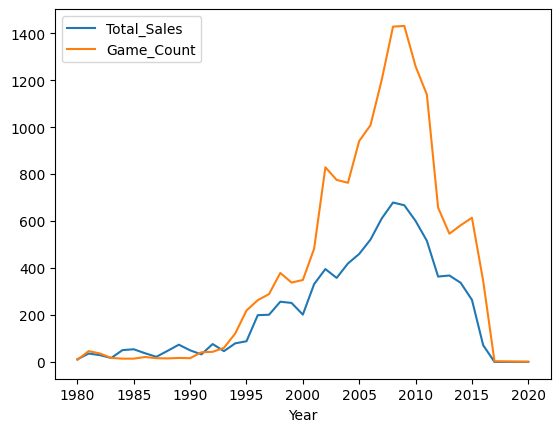

In [144]:
conc = pd.concat([sale_trend,g_per_yr],axis=1)
conc.columns = ['Total_Sales', 'Game_Count']
conc.plot()

#Observation:
#There appears to be a positive relationship between the number of games released and total global sales↓
#particularly during the growth phase of the industry (1995–2010).
#The line started declining after 2010 

#Possible explaination:
#It natural the quality and sale were have a positive correlation 


#Next analysis:
#How much the game and sale move together 
#How much Aproximate sale incrase for the each game release


In [145]:
conc.corr()

#Observation
#The correlation between total sales and game count was strongly positive as it was move togther closly with less variance 
#So whem the game count increase equally the total sales increase 

,Total_Sales,Game_Count
Total_Sales,1.00000,0.98303
Game_Count,0.98303,1.00000


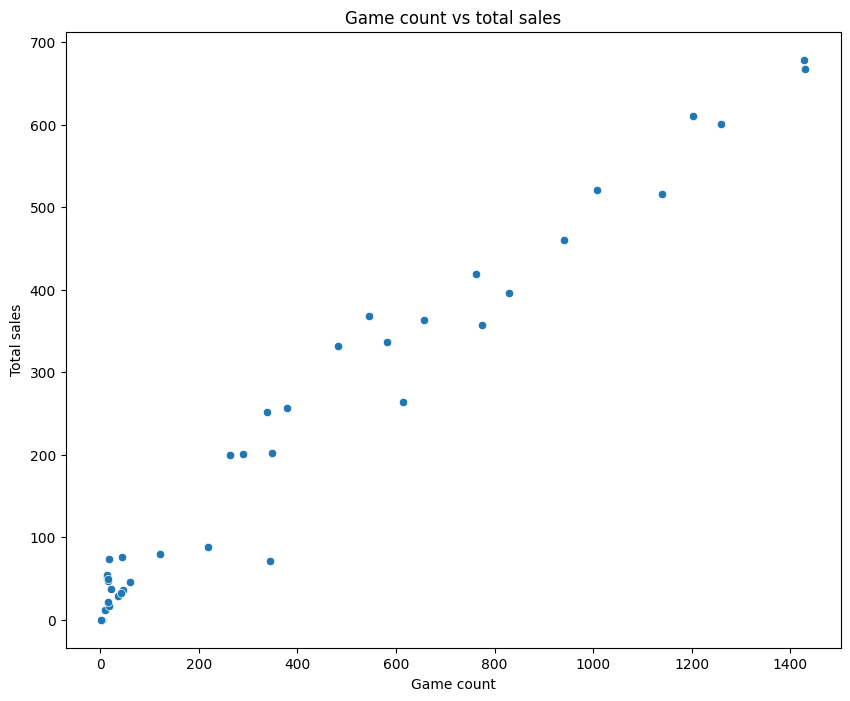

In [146]:
#Creating a scatter plot chart
#Scatter plot will help us to undertsand is the two varibale actually moving toghther will visible outliers
# x axis → Game count (independent variable)
# y axis → total sales (dependent variable)

plt.figure(figsize=(10,8))
sns.scatterplot(
    data=conc,
    x = 'Game_Count',
    y = 'Total_Sales',

)

plt.title('Game count vs total sales')
plt.xlabel('Game count')
plt.ylabel('Total sales')
plt.show()


#Observation:
#Both the variable moves togther with very mild outliers and noise
#The variables was clustered at low level yet get little scatter when both incraesed
#There is a clear positive relationship between Game_Count and Total_Sales.
#The relationship is strong, but not perfectly linear, with some visible dispersion.
#The pattern appears approximately linear, indicating proportional growth between variables.
#There are no significant outliers, only minor deviations from the trend.
#Variability increases at higher values, suggesting a weakening consistency in the relationship.

In [147]:
#Creating Ml model to predict Global sales

#Target → Global_Sales
#Features →Platform, Year, Genre

#Explaination
#year → this model can learn newer games may sell differently, certain periods have higher sales Therefore, Year helps model learn time-based trends
#Platform → Games on some platforms tend to sell more
#Genre → Certain genres tend to perform better

#Next move
#have to creat y(target) and x(features)
#encoding the string values to [1/0]

y = df['Global_Sales']  #Target   

x = df.drop(
    ['Global_Sales', 'Name', 'Publisher', 
     'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales'],
    axis=1
)

#Encodinng the features 
#Using one-hot encoding method

x = pd.get_dummies(x,drop_first=True)

#importing skilearnt library for Train_Split_Test

from sklearn.model_selection import train_test_split

#spliting the values in 80/20 ratio for train and testing 

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42                  #random_state is a number that controls the randomness, randomness ows are shuffled randomly
)

from sklearn.linear_model import LinearRegression

#Opening the Linear regression

model = LinearRegression()

#Fitting the model (fitting is complusory or else model will crash if we try to predict)

model.fit(x_train,y_train)

#X_train → inputs used to teach
#y_train → correct answers used to teach
#X_test → new questions (no
#y_test → actual answers for those questions
#y_pred → model’s predicted answers


#Creating predict 
y_pred = model.predict(x_test)  #model trained silently

#Predicting something with the created model

y_pred[:5]  #show the first 5 predictions from the test set

#Comparing the predicted answer with the y_test(existing answer because we feeded the actual data(answer) in y_test) ↓
#to see the model did well or it was underfit or overfit ......

print(y_pred[0])
y_test.iloc[0]    #They both gave different answers, yes — but that alone does NOT mean underfitting. 


0.6638270831147892


np.float64(0.33)

In [148]:
#Model Evaluation 

# Mean_absolute_error (find the difference between the actual and pred, and finds the average of the differnece )

#import the MAE from skilearn
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print(mae)

#Interpretation
#The model's predictions are off by about 0.53 million units on average.
#This means the model makes moderate errors, and performance seems reasonable but can still be improved



0.528737418222345


In [149]:
#Mean_Squared_error (Square the absolute diffference before averaging it)
#More sensitive to outlier, punishes large mistake more 
#likely to more than the MAE

#import MSE from skilearn
from sklearn.metrics import mean_squared_error
 
mse = mean_squared_error(y_test, y_pred)
print(mse)


#Iintepretation
#The MSE is significantly larger than the MAE, indicating that the model likely makes some large prediction errors.
#This suggests the presence of outliers or cases where the model performs poorly.

3.7480625538775354


In [150]:
#R-Squared 
#Helps to find the percent of the prediction pattern found 

#import R^2 from skilearn
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print(r2)



#Interpretation
#TThe R² score is around 0.12, which indicates the model explains only a small portion of the variance in Global_Sales.
#This suggests the model has weak predictive power




#Overall view  of the model after all  3 test (MAE, MSE, R^2)
# MAE ≈ 0.53
# MSE ≈ 3.75
# R² ≈ 0.12

#Interpretation
# Model was weak
# Linear Regression not capturing realtionship well 
# Your features may not explain sales strongly 
# Non - Linear model may work better (decision tree later)

0.12275543797559396


In [151]:
#Decision tree 

#A Decision Tree is a model that makes predictions by asking a series of questions (splits).
#Instead of fitting a formula, it divides the data step-by-step.
#It keeps dividing until predictions become accurate.
# Weakness → Can overfit easily


#import Decision regressor from sklearn
from sklearn.tree import DecisionTreeRegressor

#creating a variable for the model
tree_model = DecisionTreeRegressor()

#Feeding data to the model
tree_model.fit(x_train, y_train)

#Predicting the data with the x test to evaulate 
y_pred_tree = tree_model.predict(x_test)

In [152]:
#Evaluation

#importing MAE from sklearn 

#Mean_absolute_error
mae_tree = mean_absolute_error(y_test, y_pred_tree)
print(mae_tree)

#Interpretation
#The decision tree model have done the prediction with a 0.0174 variation which seems to mere to prefect shows the model did really well
#yet concern was on the model might be overfitting


0.017173913043478532


In [153]:
#importing MSE from sklearn
from sklearn.metrics import mean_squared_error

#mean_squared_error
mse_tree = mean_squared_error(y_test, y_pred_tree)
print(mse_tree)

#Interpretation
#MSE - shows a very small value compared to linear shows the model perfroms great 
#but we expect mse also at very small but it has moderate compared to the MAE thus, this shows the model still some large prediction error 


0.6770599816289037


In [154]:
#importing r^2 from sklearn
from sklearn.metrics import r2_score

# R - Squared 
r2_tree = r2_score(y_test, y_pred_tree)
print(r2_tree)

#Interpretation
#The model explains about 87% of the variance in Global_Sales, indicating strong predictive performance 

0.8415322107060792


In [155]:
#going max_depth to balance and avoid over fitting

#Starting with depth → 3 (simple)

#importing
from sklearn.tree import DecisionTreeRegressor

#Depth-3

tree_model_3 = DecisionTreeRegressor(max_depth = 3)

tree_model_3.fit(x_train, y_train)

y_pred_tree_3 = tree_model_3.predict(x_test)


In [156]:
#Evaluation

#Mean absolute error
mae_tree_3 = mean_absolute_error(y_test, y_pred_tree_3)
print(mae_tree_3)

#Interpretation
#The MAE increased compared to the unlimited tree, The simpler depth-3 tree is less likely to overfit while still maintaining good performance
#overfitting was overall been reduced well but little shows the 3 depth and unlimted doesnt make much varianace shows the simple model and complex
#model doesnt have big difference

0.17013663488572725


In [157]:
#mean squared error
mse_tree_3 = mean_squared_error(y_test, y_pred_tree_3)
print(mse_tree_3)

#Interpretation
#The MSE increased slightly compared to the unlimited tree, but remains much lower than Linear Regression ↓
#indicating the depth-3 model still performs well while being more stable

0.8468351912044793


In [158]:
# R - Squared

r2_tree_3 = r2_score(y_test, y_pred_tree_3)
print(r2_tree_3)

#Interpretation
#The R² score of about 0.80 indicates the model explains 80% of the variance, which is still strong performance.
#The slight drop from 0.87 suggests reduced complexity with improved generalization



#Conclusion
#We selected max_depth = 3 because it provides a good balance between model accuracy and generalization. 
#It significantly improves performance over Linear Regression while reducing the risk of overfitting compared to the unlimited Decision Tree

0.8017958463242605


In [159]:
# Hyperparater tuning to depth - 4

#Importing
from sklearn.tree import DecisionTreeRegressor

# Depth - 4
tree_model_4 = DecisionTreeRegressor(max_depth = 4)

tree_model_4.fit(x_train, y_train)

y_pred_tree_4 = tree_model_4.predict(x_test)


In [160]:
#Evaulation

# Mean absolute error (MAE)

mae_tree_4 = mean_absolute_error(y_test, y_pred_tree_4)
print(mae_tree_4)

#Interpretation
#The depth-4 model shows a significant improvement in the prediction compared to depth-3 at 0.094 million variation

0.09492605657524582


In [161]:
# Mean squared error

mse_tree_4 = mean_squared_error(y_test, y_pred_tree_4)
print(mse_tree_4)


#Interpretation
#The MSE shows a slight imrpovement in the  model with 0.63 million variation. Still the model make's some big prediction error
# MSE just squares the MAE so it says most of the error  varies 0.9 miilion(MAE), but some larger error goes approx to 0.6 miilion(MSE)

0.6371355954696021


In [162]:
# R - Squared 

r2_tree_4 = r2_score(y_test, y_pred_tree_4)
print(r2_tree)

#Interpretation
# Depth -4 shows a impressive improvement with 87% pattern  predicted 
#The pattern reached the percent of unllimted depth within 4 depth
#With only 4 splits depth, the tree captured almost all useful patterns.


#Conclusion
#We selected max_depth = 4 because it achieves nearly the same R² as the unlimited tree while keeping the model simpler and less prone to overfitting. 
#It improves accuracy compared to depth=3 and reaches performance saturation, indicating an optimal balance between complexity and generalization.

0.8415322107060792


In [163]:
#Validation for decision tree_depth_4 → used to find the model acutal capability 

#Cross validation (K-fold method)

#Importing
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeRegressor

#Finalsied model
tree_model_4 = DecisionTreeRegressor(max_depth=4)

scores = cross_val_score(tree_model_4, x, y, cv = 5, scoring = 'r2')   # cv → splits(fold) # here we took 5 splits

print(scores)



#Interpretation
#The cross-validation results show large variance and multiple negative R² scores
#indicating that the Decision Tree model with max_depth=4 is unstable across different data splits.
#Although the model performed well on a single train-test split
#cross-validation reveals that it does not generalize consistently and may suffer from high variance.
#Therefore, the Decision Tree is not reliable for deployment, and a more robust model such as Random Forest should be considered.

#Next step 
# Try Random Forest 
# Random forest give more stability

[ -0.22058998  -5.34260088 -13.73105766  -1.74232845 -99.25147038]


In [164]:
# Random Forest
# Random Forest is a supervised learning algorithm based on multiple decision trees.
# It builds many decision trees using random subsets of data and features.
# Each tree makes a prediction.
# The final output is obtained by majority voting (classification) or averaging (regression).
# This helps reduce overfitting and variance, leading to better accuracy.


#Importing random forest regessor from skilearn
from sklearn.ensemble import RandomForestRegressor   # Ensemble → models combining multiple learners

# Variable for the model

rf_model = RandomForestRegressor()

# Training the mdoel 

rf_model.fit(x_train, y_train)

# Basic prediction

y_rf_pred = rf_model.predict(x_test)



In [165]:
# Evaluation
# Mean Absolute Error (MAE)

rf_model_mae = mean_absolute_error(y_test, y_rf_pred)
print(rf_model_mae)

#Interpretation 
# The prediction was only 0.016 million differance shows a extremely close pattern prediction
# concern that the model may get to platue 
# MAE imporoved a lot compared to decision tree depth - 4 


0.016887109614207294


In [166]:
# Mean Squared Error (MSE)

rf_model_mse = mean_squared_error(y_test, y_rf_pred)
print(rf_model_mse)

# MSE was little  off than the decison tree shows the mdoel makes huge mistake in some prediction

0.7245720345039793


In [167]:
# R - Squared

rf_model_r2 = r2_score(y_test, y_rf_pred)
print(rf_model_r2)

# Model shows a good prediction pattern percentage of aprox. 84% shows the model prediction was good
# Decision Tree explained variance slightly better. But Decision Tree was unstable


# Conclusion
# MAE was much lower than Decison tree shows we could expect stablity overall, lower mae suggest higher consistency
# MSE is slightly higher shows the model makes some huge mistake 
# R^2 was slightly lower the model predict with less acuuracu thann the decision tree but it was realstic 
#Overall the model shows more stability than decision tree

#Next step 
# Validation to see the stability in the actually senarios 
# using k-fold cross validation method for it

0.8304118813582788


In [168]:
# Validation
# using k - fold cross validation method to chcek the model stability

#Importing
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor

# model to be validate 

rf_model = RandomForestRegressor()

# Validating
rf_scores = cross_val_score(rf_model, x, y, cv = 5, scoring = 'r2')

print(rf_scores)

#Interpreation
# The model have negative values shows the model was performed worse than the no variance 
# Validation reveals the model model was unstable in multiple slpits and not ready to deploy
# Even though the model perform good in single split the model perfroms bad in multiple splits shows the model might be overfitting ↓
# And memroized the data
# Scores have high variance 
# Current Random Forest configuration is unstable. We should tune parameters before rejecting



# Reason default model fails
# Small dataset → each fold has less data, random sampling varies more, every tree see differnet pattern and the average becomes unstable
# Bootstrap randomness → ecah tree uses random rows, each fold aslo changes data. So with limited data model shows high variance 
# Random forest is sensitive to data size and data variance 

[-0.21172332 -0.21512613  0.03302955 -0.15411152 -4.29508612]


In [169]:
# Random forest with n_estimators - 300 tree 

#Creating avriable

rf_model_300 = RandomForestRegressor(n_estimators=300)


# Fitting

rf_model_300.fit(x_train, y_train)

y_ref_pred = rf_model_300.predict(x_test)


In [170]:
#Skipping evaluation because we can skip it when were tuning hyperparameter

# Using k-fold cross validation

from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor

# Creating validation variable

rf_model_300 =  RandomForestRegressor(n_estimators = 300, random_state = 42) 
# Random_state → A number that controls randomness in machine learning algorithms.

rf_300_scores = cross_val_score(rf_model_300, x, y, cv = 5, scoring = 'r2')
print(rf_300_scores)

#Conclusion
# Yet the model perfrom is not reliable with the n-estimator shows the model fails to predict pattern
#the model has one large variance 
# Model shows high unstability in the random splits 
# Overall random forest is not reialble algorithom for the model

#Conclusion after adding random_state 
#The instability is not coming from randomness, it is coming from the dataset itself.
# Random Forest is not reliable for this feature set / dataset

#Fitting the model again because we overwrite it 
rf_model_300.fit(x_train, y_train)


[-0.21172332 -0.21532994  0.03302543 -0.15396257 -4.29508612]


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [171]:
# Checking feature importance 


# Why
# The model used every feature given and predict and it will rate evry fetaure with an imporatance number(how much it used the fetaure to predict)
# So seeing the feature importance helps to find the usefull and useless feature 
# This will help to find the feature is useful to predict or not 
# of the whole feature didn't contribute and have less importance it is likely to be useless and may affcet the prdiction so we can remove those featur

# Here we made the feature separte with one-hot encoding so we need to combined and to see the each hot(unqiue) columns to see the whole feature imp

# Making a variable for the feature importance and acess the feature importance from the trained model
importances = rf_model_300.feature_importances_
importances

#how to interpret the importances
#9.98497..... -01 = scientific notation a* 10^b
#so 9.98497.... * 10^-1 (10^-1 = 0.1), so 9,98497.... * 0.1 = 0.99849...

#3.469... -04  = scientific notation a* 10^b
# so 3.469.... * 10^-4 (10^-4 = 0.0001), so 3.469.... * 0.0001 = 0.0003469...

#Compare magnitude 
#0.99849 / 0.0003469 ≈ 2885, therefore the first feature is ≈ 2885 larger than the second feature 


#Conclusion 
# Here only one feature has the highest use rate and remaning were very small shows the model relying on only one dominant feature 


# Next step 
# Converting important values into feature names

array([9.98497837e-01, 3.46954286e-04, 0.00000000e+00, 2.30859933e-06,
       1.21280442e-10, 7.60339479e-05, 7.48071471e-05, 3.32878800e-06,
       7.33401730e-08, 5.03761620e-09, 0.00000000e+00, 2.93506110e-08,
       2.64531480e-04, 0.00000000e+00, 1.15990630e-08, 0.00000000e+00,
       6.14641835e-07, 1.72677785e-05, 1.57761834e-05, 5.61959855e-07,
       4.62223940e-08, 1.34249219e-19, 2.35156765e-19, 6.37085649e-21,
       1.15326035e-05, 0.00000000e+00, 0.00000000e+00, 7.92266656e-05,
       2.43492521e-08, 4.65599552e-06, 1.09349516e-08, 2.07763927e-09,
       1.33532380e-08, 5.18091519e-07, 2.21990257e-05, 3.43672894e-04,
       1.06245396e-05, 1.29038509e-04, 3.31586479e-05, 1.30722741e-05,
       4.92854758e-05, 2.77452756e-06, 2.92791270e-09])

In [172]:
# Converting important values into feature names

featured_importances = pd.Series(   #pd.series creates a labeled array 
    rf_model_300.feature_importances_,   #first argument
    index = x_train.columns             #second argument 
).sort_values(ascending = False)  #arrange the features values in descending order 

featured_importances.head(10)


#Interpretation
#The 'Rank' feature is the only featured used ≈ 98% prediction and remaining where more likely not used 
#This shows the all the other features in the model were, this makes the model unstable 
# imp → rank is derived from the Global_sales, a feature that directly computed from the target (this is called data leakage)
#Therefore the model is basically cheating (if rank=1 → high sales, if rank=1000 → low sales)
#model is learning artifical relationships 

#Next step
# Remove rank column and re-train the model and validate it 


Rank                  0.998498
Year                  0.000347
Genre_Platform        0.000344
Platform_NES          0.000265
Genre_Racing          0.000129
Platform_Wii          0.000079
Platform_DS           0.000076
Platform_GB           0.000075
Genre_Simulation      0.000049
Genre_Role-Playing    0.000033
dtype: float64

In [173]:
#Data engineering (we gonna drop the rank and train the model once again)

#dropping rank from the x(feature)

x_new = df.drop(
    ['Global_Sales', 'Rank', 'Name',
     'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales'],
    axis=1
)

y_new = df['Global_Sales']

x_new.columns

Index(['Platform', 'Year', 'Genre', 'Publisher'], dtype='str')

In [174]:
# One-hot encoding using sklearn 

#defining categorical cloumns
cat_cols = ['Platform', 'Genre', 'Publisher']

#importing one hot encoder from sklearn

from sklearn.preprocessing import OneHotEncoder 

#Encoding
encoder = OneHotEncoder(sparse_output = False, handle_unknown = 'ignore')  #sparse_output = False  → return normal array (easier to work with)
                                               # handle_unknown = 'ignore' → prevent crash if new category appear in the test set

#fitting encoder
encoded = encoder.fit_transform(x_new[cat_cols])  # fit → learns unique category # transfrom → convert to one hot 


# getting columns names (because now the encoded values are juts an numpy array so we can really find the feature name)
#it wont covert to string, this is for pure reference, model cares only about the data values (0,1)
encoded_cols = encoder.get_feature_names_out(cat_cols)

#coverting array and name into a data frame for easier interpretation
encoded_df = pd.DataFrame(
    encoded,
    columns=encoded_cols,
    index=x_new.index
)

#merging year as it was not string so we removed from the cat-cols so 'year' is an important feature so we have to merge it in the df
x_final = pd.concat([x_new[['Year']], encoded_df], axis=1)

x_final.shape


(16327, 621)

In [175]:
# Re-Train the model      

#data spliting 
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(   #remember the order, if order was y is numeric, y is feature matrix, x ix empty,
                                                       # model fails silently
    x_final,
    y_new,
    test_size = 0.2,    #test data size was 20%
    random_state = 42,   #randomness split of the data
)

# Training the model   

#import the model     
from sklearn.ensemble import RandomForestRegressor 

#creating the variable
new_rf_model = RandomForestRegressor(n_estimators = 300)

new_rf_model.fit(x_train, y_train) 

y_pred_new_rf = new_rf_model.predict(x_test)    

In [176]:
#evaluation

#MAE(mean absolute error)       
new_rf_mae = mean_absolute_error(y_test, y_pred_new_rf)
print(new_rf_mae)


#Interpret 
# The model have a diffrence of 0.5355 million in prediction from the actual  
# The model have a huge difference in MAE from the last trained model shows this model is more realastic 

0.5368559036541564


In [177]:
#MSE(mean squared error)
new_rf_mse = mean_squared_error(y_test, y_pred_new_rf)
print(new_rf_mse)

#Interpretation
# The model has a high MSE shows the model make some very major prediction with a loud noise and outliers
# The model has huge differnce from the previous model

4.234254306205229


In [178]:
# R - Squared 
new_rf_r2 = r2_score(y_test, y_pred_new_rf)
print(new_rf_r2)

#Interpretation
#The model has a very low prediction rate less than 1% shows the model barely predict something


#Conclusion
#Evaluation shows the model is underfitting and unstable 
# The instability because of the feature weakness 


#next step
#Check feature importance again but without leakage 
#Consider feature engineering 

0.008960893541071546


In [179]:
#Feature importance 
new_rf_imp = new_rf_model.feature_importances_


#making it to a dataframe for the better visual and understanding
feature_imp = pd.Series(
    new_rf_imp,
    index = x_final.columns
).sort_values(ascending = False)

print(feature_imp.head(10))

#Interpretation 
#The model as no data leakage and the features was queit evenly distributed 
#The feature contributes but signal was weak 


#Conclusion 
# The available features are insufficient to predict Global_Sales accurately.
# The model performance is low because the available features (Platform, Genre, Year, Publisher) provide limited predictive signal for Global_Sales.

#Next step
#Feature engineering
#Swicthing to Classificaion from regression
#There are so many classified feature than numeric so it was best to try classification


Year                  0.422254
Publisher_Nintendo    0.100463
Genre_Role-Playing    0.039703
Genre_Shooter         0.033374
Genre_Platform        0.032230
Platform_GB           0.031874
Genre_Action          0.028233
Genre_Racing          0.024938
Genre_Misc            0.022732
Platform_PS3          0.018687
dtype: float64


In [180]:
# Using classification algorithoms to tarin the model
#why
# The features have more string and labels than numbers, so it was more reliable and more stable to go with classification model

# The algorithom used to train this model was binary class (2 class [yes,no], [hit,not hit])
# Because the model gets limited data and features was not so strong and little weaker so going with baseline and less complex like binary is reliable

# Work-flow ↓
# Set threshold
# Convert numeric into binary labels 
# Check class balance 


#Threshold, we kept threshold has 33% has it was less stricter and model learns easily and to avoid class imbalance 

threshold = y_new.quantile(0.67)   #y_new is we made it earlier y_new =  Global_sales
print(threshold)

# Creating a 'Binary Target'

y_binary = (y_new >= threshold).astype(int)  #y_new >= threshold makes a boolean like false less than threshold and true from > than threshold
# astype(int) makes the boolean into 0,1

# Split of classification 
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x_final,
    y_binary,
    test_size = 0.2,  #20% for test and 80 for train
    random_state = 42,
    stratify = y_binary,   #This ensures  train set keep the 33/67 raito, this avoids randomly occuring imbalance 
)


#Testing stratification
y_train.value_counts(normalize=True)    #This shows the stratification works perfectly
y_test.value_counts(normalize=True) 

0.33


Global_Sales
0    0.663197
1    0.336803
Name: proportion, dtype: float64

In [181]:
# Creating the model 

# Importing Randomforest_classifier 

from sklearn.ensemble import RandomForestClassifier 

# Creating the model

rf_clf = RandomForestClassifier(
    n_estimators = 300,
    random_state = 42,
     class_weight = 'balanced'  #This will give more weight to the minority group to balance(it imrpoves recall but reduce the precision)
                                # use when required 
)

# Feeding the model
rf_clf.fit(x_train,y_train)

# Prediction 
y_clf_pred = rf_clf.predict(x_test)


#Next step 
#Model evaluation
# Unlike regression we wont use MAE, MSE, R^2
#WE use( Accuracy, Confusion matrix, Classification report)

In [182]:
# Evaluation
# Acuuracy 

#importing Accuracy from sklearn
from sklearn.metrics import accuracy_score 

# Accuracy test
accuracy = accuracy_score(y_test, y_clf_pred)

print(accuracy)


# Interpretation
# The model found  the 72% of the pattern 
# The Random Forest classifier achieved ~73% accuracy. Since the baseline accuracy is ~67%, the model provides a small improvement ↓
# Indicating weak but present predictive signal in the features.

0.7161665646050215


In [183]:
# Confusion matrix  

#importing connfusion matrix 
from sklearn.metrics import confusion_matrix

# Test 
cm = confusion_matrix(y_test, y_clf_pred)


#interpretation (Before class balancing)
#The model has 1762 → TN(true negative) the model predicted 1762 not hits correctly as not hit
#The model has 404 → FP(false positive) the model has predicted 404 hit has not hit. Shows the model failed to hit the acutual hit  
#The model has 486 → FN(flase negative) the model has predicted 486 not hit has hit
#The model has 614 → Tp(true Positve) the model has predicted 614 hit as hit correctly 



#interpretation (Before class balancing)
#The model has 1668 → TN(true negative) the model predicted 1668 not hits correctly as not hit
#The model has 498 → FP(false positive) the model has predicted 498 hit has noy hit. Shows the model failed to hit the acutual hit  
#The model has 429 → FN(flase negative) the model has predicted 429 not hit has hit
#The model has 671 → Tp(true Positve) the model has predicted 671 hit as hit correctly 
print(cm)

[[1668  498]
 [ 429  671]]


In [184]:
#Classification report 

from sklearn.metrics import classification_report 
print(classification_report(y_test, y_clf_pred))



#Interpretation
#The model precision of 60% in predicting hits and 56% of recall (model actually find 56% of actual hits)
#The model has precision of 78% for predicting not hits and 81% recall (model find 81% of not hits correctly)
#F1 shows the balance between both precision and recall as not hit has good balance of 80% where hit has decent balance of 58%
#Therefore,the model performs well in predicting non-hit games but struggles to correctly identify hit games, with a recall of only 56%
#ndicating many hits are missed.


#Why this happens
#hits = minority class (33%)
#features are weak
#model biased toward majority (Not Hit)


#Next step
#Class balancing (Class_weight)
#Threshold tuning
#Feature engineering 

              precision    recall  f1-score   support

           0       0.80      0.77      0.78      2166
           1       0.57      0.61      0.59      1100

    accuracy                           0.72      3266
   macro avg       0.68      0.69      0.69      3266
weighted avg       0.72      0.72      0.72      3266



In [185]:
#Class Balancing 
#interpretation after the class balancing 
#After applying class balancing, the model improved recall for the minority class (Hit) from 56% to 61% I
#Indicating better detection of hit games, with a slight drop in precision and accuracy, which is expected due to the trade-off

In [186]:
#Threshold tuning 

#Predict_proba (use to exrtact the probability for the class to find the best threshold)
y_prob = rf_clf.predict_proba(x_test)[:, 1]
print(y_prob[:10])

[0.43604028 0.71878283 0.70150334 0.67063063 0.12582399 0.12719875
 0.19488391 0.62270473 0.21522088 0.63444269]


In [187]:
#Trying Multiple threshold at once 
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

#Threshold array
threshold = np.arange(0.1, 0.9, 0.1)

#loop to try very threshold 
for t in threshold:
    y_pred_t = (y_prob >= t).astype(int)

    precision = precision_score(y_test, y_pred_t)
    recall = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)

    print(f"Threshold: {t:.1f} | Precision: {precision:.2f} | Recall: {recall:.2f} | F1: {f1:.2f}")

#model is weak after threshold tuning the model slightly improves shows the fearute is too weak

#Next step
#Feature engineering 

Threshold: 0.1 | Precision: 0.43 | Recall: 0.89 | F1: 0.58
Threshold: 0.2 | Precision: 0.48 | Recall: 0.82 | F1: 0.61
Threshold: 0.3 | Precision: 0.51 | Recall: 0.73 | F1: 0.60
Threshold: 0.4 | Precision: 0.54 | Recall: 0.68 | F1: 0.60
Threshold: 0.5 | Precision: 0.57 | Recall: 0.61 | F1: 0.59
Threshold: 0.6 | Precision: 0.62 | Recall: 0.51 | F1: 0.56
Threshold: 0.7 | Precision: 0.64 | Recall: 0.41 | F1: 0.50
Threshold: 0.8 | Precision: 0.67 | Recall: 0.29 | F1: 0.40


In [188]:
#Smoothing (to control the weight for low sample data)

#Step-1 - group total games by publisher

pub1 = df.groupby('Publisher')['Name'].count().sort_values(ascending = False)


#Were craeting a new column for extracing the hit 
threshold = df['Global_Sales'].quantile(0.67) #creating the  threshold


#creating hit columns via pandas 
df['Hit'] = (df['Global_Sales'] >= threshold).astype(int)

df['Hit'].mean()

#grouping hit by publisher 
hits = df.groupby('Publisher')['Hit'].sum().sort_values(ascending = False)
hits.head(10)

#Interpretation
#here electronic arts have the highest hits 
#the varinace between the 1 and 2nd was high 

Publisher
Electronic Arts                 824
Nintendo                        512
Activision                      441
Sony Computer Entertainment     359
Ubisoft                         337
THQ                             321
Sega                            217
Namco Bandai Games              214
Konami Digital Entertainment    205
Take-Two Interactive            199
Name: Hit, dtype: int64

In [189]:
#Concating pub1 and hits  togther 
hit_df = pd.concat([pub1, hits], axis = 1)

# Calculating hit rate
hit_df['Hit_Rate'] = hit_df['Hit'] / hit_df['Name']

global_rate = df['Hit'].mean() #overall probability of a game being a Hit in the entire dataset 
#Global hit rate = the average success rate of ALL games in the dataset (not per publisher, but overall)

global_rate 


np.float64(0.33668157040485086)

In [190]:
#smoothing manually with formula 
m = 10  # strenght given to the global percentage


hit_df['Smoothed_Hit_Rate'] = (hit_df['Hit'] + m *  global_rate) / (hit_df['Name'] + m)

hit_df

,Name,Hit,Hit_Rate,Smoothed_Hit_Rate
Publisher,,,,
Electronic Arts,1339,824,0.615385,0.613319
Activision,966,441,0.456522,0.455294
Namco Bandai Games,928,214,0.230603,0.231734
Ubisoft,918,337,0.367102,0.366775
Konami Digital Entertainment,823,205,0.249089,0.250140
...,...,...,...,...
Altron,1,0,0.000000,0.306074
CCP,1,0,0.000000,0.306074
GameTek,1,0,0.000000,0.306074


In [191]:
#Adding the smoothed value back to the dataset
df['Publisher_Score'] = df['Publisher'].map(hit_df['Smoothed_Hit_Rate'])
df



#Next step 
#Now we have an more  relaiable feature than publisher so its better to replace publisher with publisher_score 
#New x is gonna be craeted as the old one has one-hot encoded publsher, mixing these will increase model complexity 
#There is no need of normailizing for the new feature as it was in 0 to 1 form 
#Encoding is required for other categorical variables 

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Hit,Publisher_Score
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74,1,0.729981
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,1,0.729981
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82,1,0.729981
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00,1,0.729981
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,1,0.729981
...,...,...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002,Platform,Kemco,0.01,0.00,0.00,0.00,0.01,0,0.140865
16594,16597,Men in Black II: Alien Escape,GC,2003,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01,0,0.244603
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008,Racing,Activision,0.00,0.00,0.00,0.00,0.01,0,0.455294
16596,16599,Know How 2,DS,2010,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01,0,0.240487


In [192]:
#Keeping a copy of the data as to maintain safety standards 
df_original = df.copy()

In [193]:
#One - hot encoding for the categorical dimensions for the new x (features)

from sklearn.preprocessing import OneHotEncoder 

x_engineered = df[['Platform', 'Genre', 'Year', 'Publisher_Score']]

y_target = df['Hit']


#taking the normalization required columns 
req = ['Platform', 'Genre']

#Creating variable for the one hot encoding

hot_code = OneHotEncoder(sparse_output = False, handle_unknown = 'ignore')  #sparse_output = false → retruns normal array(easier to work)
                                                                    #handle_unknown = 'ignore' → ignore new features appear in the test set 


#fitting encoder 
code = hot_code.fit_transform(x_engineered[req]) # fitted and transformed to binary 


# getting columns names (because now the encoded values are juts an numpy array so we can really find the feature name)
#it wont covert to string, this is for pure reference, model cares only about the data values (0,1)
code_cols = hot_code.get_feature_names_out(req)


#coverting array and name into dataframe

code_df = pd.DataFrame(
    code,
    columns = code_cols,
    index = x_engineered.index
)


# Merging numerical columns with normailsed ones 

X_final = pd.concat([x_engineered[['Year','Publisher_Score']], code_df], axis = 1)

In [194]:
#Train and split 

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X_final,
    y_target,
    test_size = 0.2,
    random_state = 42,
    stratify = y_target  #Stratify preserves class balance across splits
    
)

#Creating model

from sklearn.ensemble import RandomForestClassifier 

rf_clf_2 = RandomForestClassifier(
    n_estimators = 300,
    random_state = 42,
    class_weight = 'balanced'  #This will give more priority to minority group to balance both 
)


#feeding the model
rf_clf_2.fit(x_train, y_train)

#Gieving answer to predict 
y_clf_pred_1 = rf_clf_2.predict(x_test)


#Next step

#Model has been trained and ready for the test
#Going in order as first acuuracy test then confusion matrix then at last clasification report 

In [195]:
#Evaluation

#Accuracy 

#importing 

from sklearn.metrics import accuracy_score

clf_acc = accuracy_score(y_test, y_clf_pred_1)

clf_acc

#Interpretation
#the model has similar accuray has the previous one 
#The model correctly predicts ~71% of all games (both Hit and Not Hit combined)
#Accuracy is around 71%, which is similar to previous performance, indicating that feature engineering did not significantly improve overall accuracy.

0.7118799755052051

In [196]:
#Confusion matrix

from sklearn.metrics import confusion_matrix

confusion =  confusion_matrix(y_test, y_clf_pred_1)

confusion

#Interpretation
#The model has TN of 1647 as it found the 1647 Not Hit correctly 
#The model has FP of 519 as it incorrectly predicts 519 not hit as hits 
#The model has FN 422 as it predicts 422 hits as not hits 
#The model has TP of 678 as it found 678 hits correctly
#The model shows improvement in detecting Hits (678 correctly identified), but still misses a significant number of Hits (422)
#Indicating recall can be further improved 

array([[1647,  519],
       [ 422,  678]])

In [197]:
#Classification report 

from sklearn.metrics import classification_report

report = classification_report(y_test, y_clf_pred_1)

print(report)

#Interpretation 
#The model still struggles to detect all Hit games, with a recall of 62%, meaning a significant portion of Hits are missed
#he model shows slight improvement in detecting Hits, but performance is still moderate, with room for improvement in both precision and recall.


#Next step 
#As there is stil room for improvemet feature engineering will be more reliable than jumping into new algorithm
#Feature engineering 

              precision    recall  f1-score   support

           0       0.80      0.76      0.78      2166
           1       0.57      0.62      0.59      1100

    accuracy                           0.71      3266
   macro avg       0.68      0.69      0.68      3266
weighted avg       0.72      0.71      0.71      3266



In [198]:
#Feature engineering 

#Creating another feature that shows the hit rate of wach genre 

genre = df.groupby('Genre')['Name'].count().sort_values(ascending = False)
genre

#Grouping hits by genre 

gen_hit = df.groupby('Genre')['Hit'].sum()
gen_hit 

# Interpretation
# Action has the most hits and most games aswell
# Raw hit counts are not enough because genres have different numbers of total games
# We need Hit Rate to measure success proportion fairly across genres

Genre
Action          1177
Adventure        154
Fighting         324
Misc             505
Platform         396
Puzzle           131
Racing           440
Role-Playing     502
Shooter          562
Simulation       274
Sports           898
Strategy         134
Name: Hit, dtype: int64

In [199]:
# Conctaing genre and gen_hit 

hits_df = pd.concat([genre, gen_hit], axis = 1)

#Caculating hit rate for genre 
hits_df['Gen_hit_rate'] = hits_df['Hit'] / hits_df['Name']


#Smoothing 
hits_df['smoothed_gen_hit'] = (hits_df['Hit'] + m * global_rate) / (hits_df['Name'] + m)

hits_df


# Interpretation
# This is the final hit rate for all the genre in the games..... 


#Next step 
# Replace the genre in with the genre hit rate 
# Encode the label feature 'Platfrom'
# Retrain the model and evaluate 

,Name,Hit,Gen_hit_rate,smoothed_gen_hit
Genre,,,,
Action,3253,1177,0.361820,0.361743
Sports,2304,898,0.389757,0.389528
Misc,1710,505,0.295322,0.295562
Role-Playing,1471,502,0.341264,0.341234
Shooter,1282,562,0.438378,0.437590
Adventure,1276,154,0.120690,0.122369
Racing,1226,440,0.358891,0.358711
Platform,876,396,0.452055,0.450753
Simulation,851,274,0.321974,0.322145


In [200]:
#Adding the smoothed value back to the dataset
df['Genre_score'] = df['Genre'].map(hits_df['smoothed_gen_hit'])
df

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Hit,Publisher_Score,Genre_score
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74,1,0.729981,0.389528
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,1,0.729981,0.450753
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82,1,0.729981,0.358711
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00,1,0.729981,0.389528
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,1,0.729981,0.341234
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002,Platform,Kemco,0.01,0.00,0.00,0.00,0.01,0,0.140865,0.450753
16594,16597,Men in Black II: Alien Escape,GC,2003,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01,0,0.244603,0.437590
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008,Racing,Activision,0.00,0.00,0.00,0.00,0.01,0,0.455294,0.358711
16596,16599,Know How 2,DS,2010,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01,0,0.240487,0.231268


In [201]:
#One - hot encoding the Labels column 

from sklearn.preprocessing import OneHotEncoder 

x_eng = df[['Genre_score', 'Platform', 'Publisher_Score', 'Year']]

y_hit1 = df['Hit']

#Variable for label feature 
req1 = ['Platform']

#One- hot encoding variable
one_hot = OneHotEncoder(sparse_output = False, handle_unknown = 'ignore') #sparse = Return normal array, handle = handle errors

#fitting the label feature 
code1 = one_hot.fit_transform(x_eng[req1])

# getting columns names (because now the encoded values are juts an numpy array so we can really find the feature name)
#it wont covert to string, this is for pure reference, model cares only about the data values (0,1)
code_cols1 = one_hot.get_feature_names_out(req1)

#converting into datframe 
code_df1 = pd.DataFrame(
    code1,
    columns = code_cols1,
    index = x_eng.index
)


#concating all into a single variable 

x_final1 = pd.concat([x_eng[['Genre_score', 'Publisher_Score', 'Year']], code_df1], axis = 1)


In [202]:
# Train & Split

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x_final1,
    y_hit1,
    test_size = 0.2,
    random_state = 42,
    stratify = y_target  #Stratify preserves class balance across splits
)


#Create the algorithm 

from sklearn.ensemble import RandomForestClassifier 

rf_clf_3 = RandomForestClassifier(
    n_estimators = 300,
    random_state = 42,
    class_weight = 'balanced' #This will give more priority to minority group to balance both 
)

#feeding train data to the model

rf_clf_3.fit(x_train, y_train)

#feeding test data 
y_pred_3 = rf_clf_3.predict(x_test)

#Next step

#Model has been trained and ready for the test
#Going in order as first acuuracy test then confusion matrix then at last clasification report

In [203]:
#Accuracy test 

from sklearn.metrics import accuracy_score

acc_3 = accuracy_score(y_test, y_pred_3)

print(acc_3)

# Interpretation 
# Adding Genre_Score produced only a small improvement in overall accuracy, indicating that Genre adds limited additional predictive power 

0.7167789344764237


In [204]:
#Confusion matrix

from sklearn.metrics import confusion_matrix

matrix_3 = confusion_matrix(y_test, y_pred_3)

print(matrix_3)



#Interpretation
# TN → The model predictd 1667 not hit correctly
# FP → the model falsely predicted 499 negative as positive 
# FN → Model falsely predicts 426 positive as negative
# TP → Model predicts 674 hits correctly

#Yet the model is good at not hits and needs improvemnt at hits 

[[1667  499]
 [ 426  674]]


In [205]:
#Classification report 

from sklearn.metrics import classification_report

cr_3 = classification_report(y_test, y_pred_3)
print(cr_3)


# Interpretation
# The model struggles at predicting hits corrrectly and perferome below average
# Model is decent at predicting not hits 
# Yet the feature is seems to be improved to get balance in the data as not hit has more weightage makes the model good at not hits
# Therefore, Not every engineered feature improves the model significantly. as genre hit score didnt make any changes


#Next step 
# Feature interaction as still feature can be improved we're  going to feature interaction

              precision    recall  f1-score   support

           0       0.80      0.77      0.78      2166
           1       0.57      0.61      0.59      1100

    accuracy                           0.72      3266
   macro avg       0.69      0.69      0.69      3266
weighted avg       0.72      0.72      0.72      3266



In [206]:
#Feature interaction (combining two or more feature that give better learning for the model when combined)

#Creating a new column = publisher-genre 

df['Publisher_genre'] = df['Publisher'] + " - " + df['Genre']

# Total games by each publisher genre 
pu_gen = df.groupby('Publisher_genre')['Name'].count()

# Sum of hit by publisher genre 
pub_sum = df.groupby('Publisher_genre')['Hit'].sum().sort_values(ascending = False)

pub_sum


#Interpretation
#only few genre wa dominant in the dataset as it may cause overfiiting and model memorization of data 
#Required strong smoothing to balance the weights


#Next step (pipeline)
#Create publisher_genre_hitrate 
#Smooth it strongly 
#map 
#Create model 

Publisher_genre
Electronic Arts - Sports    372
Activision - Action         127
Electronic Arts - Racing    100
Electronic Arts - Action     99
Activision - Shooter         99
                           ... 
unknown - Platform            0
unknown - Puzzle              0
unknown - Racing              0
unknown - Role-Playing        0
unknown - Simulation          0
Name: Hit, Length: 1832, dtype: int64

In [207]:
#Concatination
hits4 = pd.concat([pu_gen, pub_sum], axis = 1)

hits4['pub_gen_rate'] = hits4['Hit'] / hits4['Name']

# Smoothing 

m1 = 40 # strong m to blance sparse data 

hits4['Smoothed_publisher_genre'] = (hits4['Hit'] + m1 * global_rate) / (hits4['Name'] + m1)

#Mapping it to the base df

df['Publisher_genre_score'] = df['Publisher_genre'].map(hits4['Smoothed_publisher_genre'])


df['Publisher_genre_score'].isnull().sum()

#Guess there will be unknwon instead if NaN 
df['Publisher_genre'].str.contains('Unknown').sum()

#So there is no NaN values so no need of filling or remoeving the values 

#Next step pipepline 
#Replace the publisher and genre score with publisher_genre_score and only platfrom and year 
#Encode 'platfrom' with one - hot encoding 
#Test train split 
#Train the model
#Run evaluation

np.int64(100)

In [208]:
#X & Y variables 

x_eng1 = df[['Publisher_genre_score',  'Year', 'Platform']]

y4 = df['Hit']

#Variable for label feature 
req2 = ['Platform']

#Feature transfromation

from sklearn.preprocessing import OneHotEncoder

one_hot1 = OneHotEncoder( sparse_output = False, handle_unknown = 'ignore')

code2 = one_hot1.fit_transform(x_eng1[req2])

# getting columns names (because now the encoded values are juts an numpy array so we can really find the feature name)
#it wont covert to string, this is for pure reference, model cares only about the data values (0,1)
code_cols2 = one_hot.get_feature_names_out(req2)

#converting into datframe 
hits4_df = pd.DataFrame(
    code2,
    columns = code_cols2,
    index = x_eng1.index 
)

#concating all into a single variable 

x_final4 = pd.concat([x_eng1[['Publisher_genre_score',  'Year']], hits4_df], axis = 1)


In [209]:
# Train & split 

from sklearn.model_selection import train_test_split 


x_train, x_test, y_train, y_test = train_test_split(
    x_final4,
    y4,
    random_state = 42,
    stratify = y4 #Stratify preserves class balance across splits
)

In [210]:
# Creating model 

from sklearn.ensemble import RandomForestClassifier 

rf_clf_4 = RandomForestClassifier(
    n_estimators = 300,
    random_state = 42,
    class_weight = 'balanced'
)


#Feeding train data 

rf_clf_4.fit(x_train, y_train)

#Predicting test set 

y_pred_4 = rf_clf_4.predict(x_test)

In [211]:
#Evalutaion

#Accuracy test 

from sklearn.metrics import accuracy_score

acc_4 = accuracy_score(y_test, y_pred_4)

print(acc_4)


#Interpretation 
#We can see a noticable imporvement in the accuracy 
#The new feature helps in minor improvemnt 

0.7246447819696228


In [212]:
#Confusion matrix 

from sklearn.metrics import confusion_matrix 

cf_4 = confusion_matrix(y_test, y_pred_4)

print(cf_4)

#Interpretation
#TN → The model predicts 2105 not hits correctly
#FP → The model predicts 603 negative as positive incorrectly 
#FN → The model predicts 521 Postive as negative incorrectly 
#TN → The model predicts 853 positive correctly 

#Overall, in confusion matrix performs much better than that last model shows the feature gives a important boost to the model

[[2105  603]
 [ 521  853]]


In [213]:
# Classification report

from sklearn.metrics import classification_report 

cr_4 = classification_report(y_test, y_pred_4)

print(cr_4)

# Interpretation 
# Even though the improvemnt in the confusion matrix are better in classification report the overall improvement was significantly low 
# Still the model struggles in predicting hit even with noticable improvement 
# Not hit was good and with a minor improvement 
#Overall model is good but no sufficient 


#Next step 
# Moving to more complex model to imrpove the recall 
#XGboost model suits well in this case

              precision    recall  f1-score   support

           0       0.80      0.78      0.79      2708
           1       0.59      0.62      0.60      1374

    accuracy                           0.72      4082
   macro avg       0.69      0.70      0.70      4082
weighted avg       0.73      0.72      0.73      4082



In [214]:
#XGBoost

from xgboost import XGBClassifier


#Model creation

xgb = XGBClassifier(
    n_estimators =  100,
    max_depth = 4,
    learning_rate = 0.05, 
    random_state = 42,
    eval_metric = 'logloss'
)


#Fitting and predicting will use same test_train_split as lost as only model changes and the feature, split and preprocessing are same 

xgb.fit(x_train, y_train)

#Predict 
y_xgb_pred = xgb.predict(x_test)

In [215]:
#Evaluation

#Accuracy 

from sklearn.metrics import accuracy_score

xgb_acc = accuracy_score(y_test, y_xgb_pred)

print(xgb_acc)

# Interpretation
# As expected the accuracy of the model has an significal improvement with an good change of 3.9 % approx 

0.7633512983831455


In [216]:
# Confusion matrix 


from sklearn.metrics import confusion_matrix 

xgb_con = confusion_matrix(y_test, y_xgb_pred)

print(xgb_con)

# Interpretation
# TN → Model predicts 2284 not hit correctly 
# FP → Model wrongly predicts 424 not hit as hits 
# FN → Model wrongly predicts 542 hits as not hits
# TP → Model predicts 832 hits correct 

# Overall, model gets a trade of in recall for accuracy 

[[2284  424]
 [ 542  832]]


In [217]:
# Classification Report

from sklearn.metrics import classification_report 

xgb_cr = classification_report(y_test, y_xgb_pred)

print(xgb_cr)

# Interpretation
# TXGBoost significantly improved overall classification performance and reduced false positives.
# The model became more precise in predicting Hits, though Recall slightly decreased compared to RandomForest.
# Hits shows a minor improvemnt yet the model stil stugless in finding hit 


#Next step
#Treshold optimization

              precision    recall  f1-score   support

           0       0.81      0.84      0.83      2708
           1       0.66      0.61      0.63      1374

    accuracy                           0.76      4082
   macro avg       0.74      0.72      0.73      4082
weighted avg       0.76      0.76      0.76      4082



In [218]:
#Threshold tuning 
# Using predict probs to see the probability of the hit and not hits in x_test

Y_prob = xgb.predict_proba(x_test)[:,1]  #[:,1] → gives only probability of 1(hit)
print(Y_prob[:10])

[0.1245474  0.04268346 0.5969563  0.33372757 0.40204278 0.35268947
 0.40658122 0.44198117 0.6494057  0.537118  ]


In [219]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

# Threshold values
threshold1 = [0.2,0.3, 0.4, 0.5, 0.6, 0.7, 0.1]

# Trying different thresholds
for t in threshold1:
    
    # Convert probabilities into 0 or 1 using threshold
    y_pred_t = (Y_prob >= t).astype(int)

    # Evaluation metrics
    precision = precision_score(y_test, y_pred_t)
    recall = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)

    # Printing results
    print(f"Threshold: {t:.1f} | Precision: {precision:.2f} | Recall: {recall:.2f} | F1: {f1:.2f}")

#Interpretation
# model as good f1 and recall with threshold 0.3 and 0.4 

Threshold: 0.2 | Precision: 0.52 | Recall: 0.90 | F1: 0.66
Threshold: 0.3 | Precision: 0.57 | Recall: 0.84 | F1: 0.68
Threshold: 0.4 | Precision: 0.62 | Recall: 0.74 | F1: 0.67
Threshold: 0.5 | Precision: 0.66 | Recall: 0.61 | F1: 0.63
Threshold: 0.6 | Precision: 0.72 | Recall: 0.39 | F1: 0.50
Threshold: 0.7 | Precision: 0.78 | Recall: 0.19 | F1: 0.30
Threshold: 0.1 | Precision: 0.42 | Recall: 0.98 | F1: 0.59


In [220]:
#Validation

#Stratified validation for classifier 

from sklearn.model_selection import StratifiedKFold

scv = StratifiedKFold(
    n_splits = 5,  #dataset divided into 5 balanced fold - train on 4, validate on 1 and repeat 5 times
    shuffle = True,  # Ensures  distribution to avoid bias 
    random_state = 42
)

In [221]:
cv_val = cross_val_score(
    xgb,
    x_final4,
    y4,
    cv = scv , 
    scoring = 'recall'
)

print(cv_val)

# Interpretation
# The model perfromance was decent in validation aswell
# No big differnce between folds 
# The model generalize around 60% recall with 50% threshold
# Its a good output where the model perfrome at a stable rate across fold 

[0.61727273 0.61363636 0.60509554 0.62693358 0.5878071 ]


In [222]:
print(cv_val.std())
print(cv_val.mean())

# Interpretation
# The std of the model shows the model has less variance not data not spreaded 
# The mean of the folds where around 61% shows all the folds are around 61% as std was less 

0.013185819985616532
0.6101490611299529


In [223]:
# Hypertuning for XGBoost model 

#Testing → min_child_weights to stable and let valid split to take

min_child = [1, 3, 5, 7, 10]

#Creating the loop and the model to check the validation score for  each weights 

from sklearn.model_selection import cross_val_score

# Creating loop 

for mc in min_child:

    #creating model 
    xgb1 = XGBClassifier(
        n_estimators = 400,
        max_depth = 4,
        learning_rate = 0.05,
        min_child_weight = mc,
        random_state = 42,
        eval_metric = 'logloss'
    )

    #Creating cross validation model
    cv_scores = cross_val_score(
        xgb1,
        x_final4,
        y4,
        cv = scv,
        scoring = 'recall'
    )

    print(f"\n min_child_weight = {mc}")   #\n → new line 
    print("fold recall scores: ", cv_scores)
    print("mean recall: ", np.mean(cv_scores))
    print("std recall: ", np.std(cv_scores))



# Interpretation 

# min_child = 1
# The model has a stable recall around 60 - 62 score
# The model has the mean of 62
# The std was aslo low as model learns less varinace 

# min_child = 3
# The model has a stable recall around 60 - 63 score
# The model has the mean of 62
# The std was less compared to last one keep as this is the current choice 

# min_child = 5 
# Here the model has a stable 60 - 63 score
# The mean is 61.7 little less compared to previous ones 
# But the std was comparitively very less than previous one keep this as the choice 

# min_child = 7
# Here the model has a stable 60 - 63 score
# The mean was 62
# The std was close to previous yet the min_child = 5 stand as the choice

# min_child = 10
# The model has the stble score of 60 - 62.5 
# With the mean of 62
# This weight has the least varinace among all with 0.05 gives the relaiable choice 

#Overall 
#The model is not highly sensitive to min_child_weight in this range
# The model is already stable as min_child is not the bottle neck 

# Next step
# As min_child is not the bottle neck 
# We're moving to Subsample parameter .....


 min_child_weight = 1
fold recall scores:  [0.62909091 0.62454545 0.61237489 0.63057325 0.60145587]
mean recall:  0.6196080734552072
std recall:  0.011102778841954746

 min_child_weight = 3
fold recall scores:  [0.63       0.62636364 0.6132848  0.62511374 0.60145587]
mean recall:  0.6192436098932914
std recall:  0.010514411254479236

 min_child_weight = 5
fold recall scores:  [0.62       0.62181818 0.61055505 0.62966333 0.6078253 ]
mean recall:  0.6179723715774672
std recall:  0.007919089043355186

 min_child_weight = 7
fold recall scores:  [0.62272727 0.62181818 0.61055505 0.63148317 0.60600546]
mean recall:  0.6185178261229216
std recall:  0.009128822060509655

 min_child_weight = 10
fold recall scores:  [0.62363636 0.61545455 0.61419472 0.62511374 0.61237489]
mean recall:  0.6181548515179089
std recall:  0.005193368347627647


In [229]:
# Sub-sample hyperparameter (giving random rows to tress to reduce memorization)

sub_sample = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

#Creating loop

for ss in sub_sample:
    
    # Creating model
    xgb2 = XGBClassifier(
        n_estimators = 400,
        max_depth = 4,
        learning_rate = 0.05,
        min_child_weight = 10,
        subsample = ss,
        random_state = 42,
        eval_metric = 'logloss'
    )

    # stratified Cross validation
    cv_scores1= cross_val_score(
        xgb2,
        x_final4,
        y4,
        cv = scv,
        scoring = 'recall'
    )

    print(f"\n Sub_sample = {ss}")   #\n → new line 
    print("fold recall scores: ", cv_scores1)
    print("mean recall: ", np.mean(cv_scores1))
    print("std recall: ", np.std(cv_scores1))


#Interpretation
# Among all the subsample 0.5 has the better stability and variance
# But the score was same as usual and there is not big differnce over 
# Therefore sub_sample is also not the bottle neck


 Sub_sample = 0.5
fold recall scores:  [0.62090909 0.61909091 0.61237489 0.6232939  0.61510464]
mean recall:  0.618154686078253
std recall:  0.003939128816714517

 Sub_sample = 0.6
fold recall scores:  [0.61545455 0.62454545 0.61055505 0.62511374 0.60236579]
mean recall:  0.615606915377616
std recall:  0.00861567444720325

 Sub_sample = 0.7
fold recall scores:  [0.61727273 0.62454545 0.60236579 0.63057325 0.61055505]
mean recall:  0.6170624534700968
std recall:  0.009969146426321792

 Sub_sample = 0.8
fold recall scores:  [0.62454545 0.62363636 0.61419472 0.63239308 0.61055505]
mean recall:  0.6210649350649351
std recall:  0.007806545168013951

 Sub_sample = 0.9
fold recall scores:  [0.62545455 0.63181818 0.62056415 0.63512284 0.61237489]
mean recall:  0.6250669203408057
std recall:  0.008102023951313077

 Sub_sample = 1.0
fold recall scores:  [0.62363636 0.61545455 0.61419472 0.62511374 0.61237489]
mean recall:  0.6181548515179089
std recall:  0.005193368347627647
